# See the difference in the Coleau fix

```
! Maximum available capacity for liquid water according to Coleou, 1998
poro = (rhoi-Rho(ind_z))/rhoi
maxpore = 0.017 + 0.057 * (poro/(1.-poro))

if (test_coleau_fix) then
    maxpore = maxpore / ( 1 - maxpore )
endif
```

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [2]:
filepath_fix = "/home/nld4814/scratch/test_coleau_fix/output"
filepath_og  = "/home/nld4814/scratch/run_FGRN055-era055_1939-2023/output"

# Columns included in the fix test run
cols = list(range(8559, 8621))

# Time axis: 30803 daily steps covering 1939-2023
t_daily = np.arange(30803) / 365.25 + 1939.0

# Time axis for 2D files: 1026 monthly (~30-day) steps
t_monthly = np.arange(1026) / 12.17 + 1939.0  # ~12.17 steps/yr

def load_1D(basepath, col):
    ds = xr.open_dataset(f'{basepath}/FGRN055_era055_1D_{col}.nc')
    return ds.assign_coords(ind_t=t_daily)

def load_2D(basepath, col):
    ds = xr.open_dataset(f'{basepath}/FGRN055_era055_2D_{col}.nc')
    return ds.assign_coords(ind_t=t_monthly)

def load_1D_all(basepath, cols):
    dsets = [load_1D(basepath, c).expand_dims({'col': [c]}) for c in cols]
    return xr.concat(dsets, dim='col')

print(f"Columns: {cols[0]}–{cols[-1]}  ({len(cols)} total)")

Columns: 8559–8620  (62 total)


In [ ]:
# Load 1D data for all columns (fix and og)
ds_fix_all = load_1D_all(filepath_fix, cols)
ds_og_all  = load_1D_all(filepath_og,  cols)

## 1D time series — single column

Compare key water variables for one representative column.
`TotLwc` is the most direct signal of the fix (more water retained per layer → higher column-integrated LWC).
`refreeze` shows the downstream effect on latent heat release.

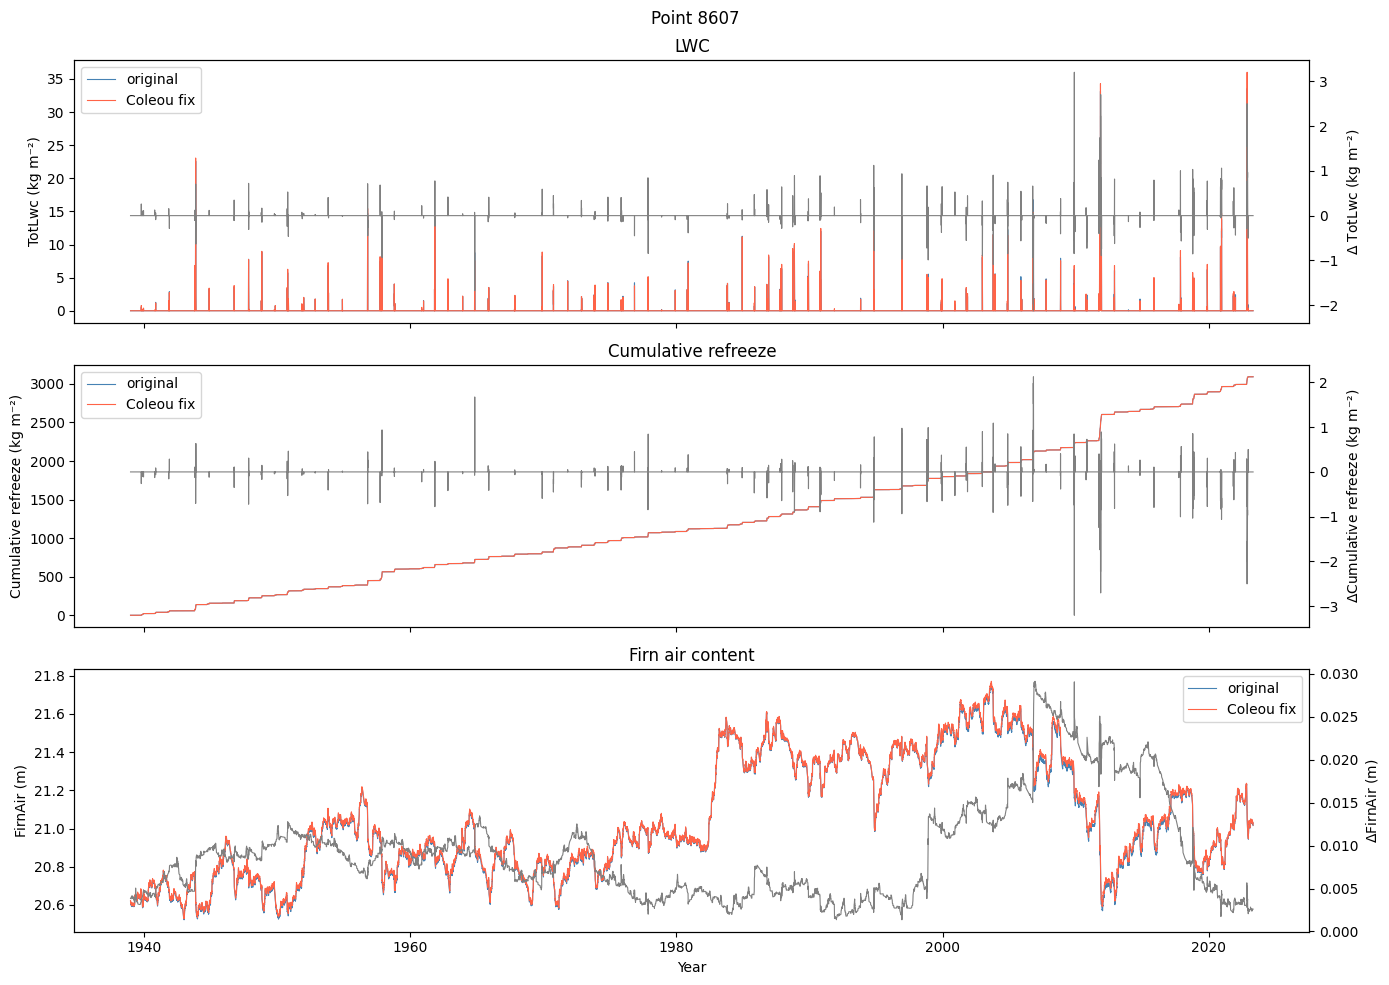

In [16]:
col = 8607  # representative column

fix = load_1D(filepath_fix, col)
og  = load_1D(filepath_og,  col)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# TotLwc
ax = axes[0]
ax.plot(t_daily, og['TotLwc'],  label='original', color='steelblue', lw=0.8)
ax.plot(t_daily, fix['TotLwc'], label='Coleou fix', color='tomato',    lw=0.8)
ax.set_ylabel('TotLwc (kg m⁻²)')
ax.set_title(f'LWC')
ax.legend(loc="upper left")

# diffTotLwc
ax = ax.twinx()
ax.plot(t_daily, fix['TotLwc']-og['TotLwc'],  label='diff', color='gray', lw=0.8)
ax.set_ylabel(f'$\Delta$ TotLwc (kg m⁻²)')

# Cumulative refreeze
ax = axes[1]
ax.plot(t_daily, np.cumsum(og['refreeze']),  label='original', color='steelblue', lw=0.8)
ax.plot(t_daily, np.cumsum(fix['refreeze']), label='Coleou fix', color='tomato',    lw=0.8)
ax.set_ylabel('Cumulative refreeze (kg m⁻²)')
ax.set_title('Cumulative refreeze')
ax.legend(loc="upper left")

# Cumulative refreeze
ax = ax.twinx()
ax.plot(t_daily, np.cumsum(fix['refreeze'])-np.cumsum(og['refreeze']),  label='diff', color='gray', lw=0.8)
ax.set_ylabel(f'$\Delta$Cumulative refreeze (kg m⁻²)')

# FirnAir
ax = axes[2]
ax.plot(t_daily, og['FirnAir'],  label='original', color='steelblue', lw=0.8)
ax.plot(t_daily, fix['FirnAir'], label='Coleou fix', color='tomato',    lw=0.8)
ax.set_ylabel('FirnAir (m)')
ax.set_xlabel('Year')
ax.set_title('Firn air content')
ax.legend()

ax = ax.twinx()
ax.plot(t_daily, fix['FirnAir']-og['FirnAir'],  label='diff', color='gray', lw=0.8)
ax.set_ylabel(f'$\Delta$FirnAir (m)')

plt.suptitle(f"Point {col}")
plt.tight_layout()
plt.show()

In [19]:
ds_fix_all

<xarray.Dataset> Size: 138MB
Dimensions:   (col: 62, ind_t: 30803)
Coordinates:
  * col       (col) int64 496B 8559 8560 8561 8562 8563 ... 8617 8618 8619 8620
  * ind_t     (ind_t) float64 246kB 1.939e+03 1.939e+03 ... 2.023e+03 2.023e+03
Data variables: (12/18)
    h_surf    (col, ind_t) float32 8MB 0.0004407 -0.0002131 ... 0.1656 0.1614
    vice      (col, ind_t) float32 8MB -0.2866 -0.2866 ... -0.6033 -0.6033
    vacc      (col, ind_t) float32 8MB 0.3238 0.004672 0.008625 ... 0.0 0.0
    vfc       (col, ind_t) float32 8MB -9.318e-06 -1.166e-05 ... -0.9861 -0.9822
    vmelt     (col, ind_t) float32 8MB -0.0009828 -0.002372 ... 0.0 0.0
    vbouy     (col, ind_t) float32 8MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    ...        ...
    refreeze  (col, ind_t) float32 8MB 0.002453 0.005918 0.0006599 ... 0.0 0.0
    rain      (col, ind_t) float32 8MB 0.0 0.0 0.0 0.03288 ... 0.0 0.0 0.0 0.0
    surfmelt  (col, ind_t) float32 8MB 0.002453 0.005918 0.0006599 ... 0.0 0.0
    solin     (col, ind_t) float32 8MB 0.582 0.09802 0.09404 ... 0.02166 0.05247
    icemass   (col, ind_t) float32 8MB 3.75e+04 3.75e+04 ... 1.371e+05 1.371e+05
    Rho0      (col, ind_t) float32 8MB 330.8 330.8 330.8 ... 304.7 304.7 304.7
Attributes:
    title:                                    IMAU-FDM 1D output file
    institution:                              Institute for Marine and Atmosp...
    source:                                   IMAU-FDM version 1.2+
    history:                                  Created on: Thu Mar 19 14:59:33...
    model_start_datetime:                     1939-09-01T00:00:00
    model_end_datetime:                       2023-12-31T21:00:00
    domain:                                   FGRN055
    forcing:                                  
    name_of_dimension:                        Number of timesteps
    timestep_length_of_dimension_in_seconds:  86400
    description_of_dimension:                 Number of timesteps (defined in...

## All columns — mean difference

Show the mean and spread of (fix − original) across all 62 columns for TotLwc and refreeze.

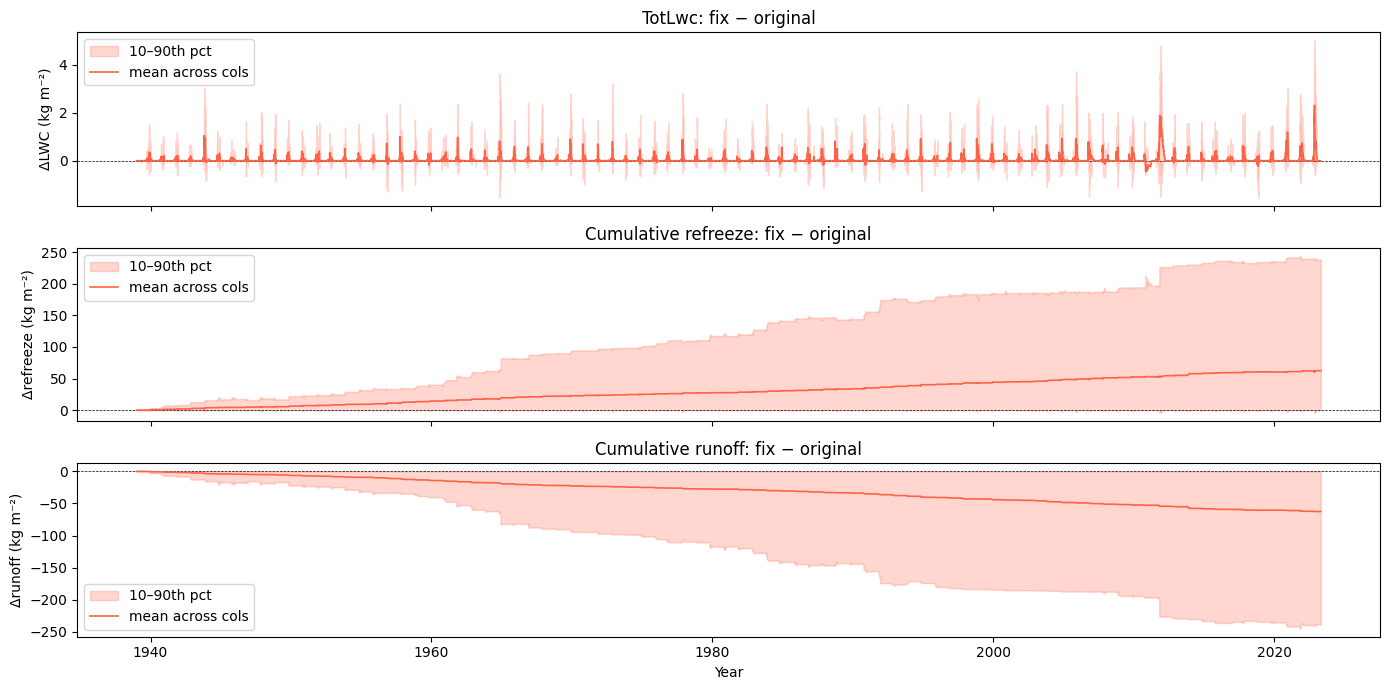

In [22]:
diff = ds_fix_all - ds_og_all  # (col, ind_t)

fig, axes = plt.subplots(3, 1, figsize=(14, 7), sharex=True)

for var, ax, title, ylabel in [
    ('TotLwc',   axes[0], 'TotLwc: fix − original',            'ΔLWC (kg m⁻²)'),
    ('refreeze', axes[1], 'Cumulative refreeze: fix − original','Δrefreeze (kg m⁻²)'),
    ('Runoff', axes[2], 'Cumulative runoff: fix − original','Δrunoff (kg m⁻²)')
]:
    if (var == 'refreeze') or (var == 'Runoff'):
        data = diff[var].cumsum(dim='ind_t')
    else:
        data = diff[var]

    mean = data.mean(dim='col').values
    p10  = np.percentile(data.values, 10, axis=0)
    p90  = np.percentile(data.values, 90, axis=0)

    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.fill_between(t_daily, p10, p90, alpha=0.25, color='tomato', label='10–90th pct')
    ax.plot(t_daily, mean, color='tomato', lw=1.2, label='mean across cols')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

axes[-1].set_xlabel('Year')
plt.tight_layout()
plt.show()

Mean FAC difference (fix − original):
  Time-and-column mean: 0.0415 m
  Std across columns:   0.0680 m
  Min / Max:            -0.0000 / 0.2828 m


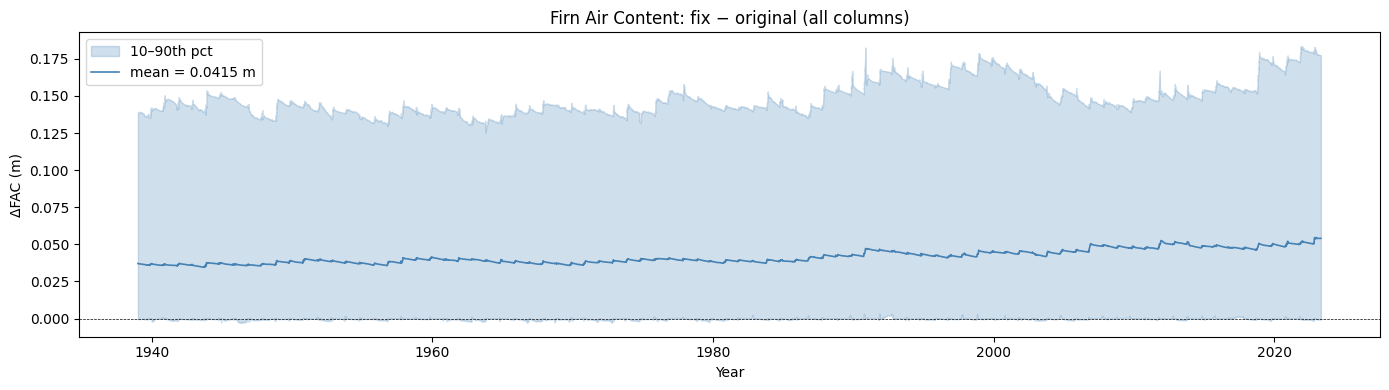

In [9]:
# Mean FAC difference (fix − original)
fac_diff = (ds_fix_all - ds_og_all)['FirnAir']  # (col, ind_t)

mean_diff = fac_diff.mean(dim='col').values
p10 = np.percentile(fac_diff.values, 10, axis=0)
p90 = np.percentile(fac_diff.values, 90, axis=0)

# Overall time-mean per column, then across columns
col_means = fac_diff.mean(dim='ind_t').values  # one value per column
print(f"Mean FAC difference (fix − original):")
print(f"  Time-and-column mean: {col_means.mean():.4f} m")
print(f"  Std across columns:   {col_means.std():.4f} m")
print(f"  Min / Max:            {col_means.min():.4f} / {col_means.max():.4f} m")

fig, ax = plt.subplots(figsize=(14, 4))
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.fill_between(t_daily, p10, p90, alpha=0.25, color='steelblue', label='10–90th pct')
ax.plot(t_daily, mean_diff, color='steelblue', lw=1.2, label=f'mean = {col_means.mean():.4f} m')
ax.set_ylabel('ΔFAC (m)')
ax.set_xlabel('Year')
ax.set_title('Firn Air Content: fix − original (all columns)')
ax.legend()
plt.tight_layout()
plt.show()

## 2D LWC depth profile — fix vs original

Time–depth cross-section of liquid water content for one column.
Layer 0 = deepest (~122 m), layer 2999 ≈ surface; here we use the `depth` variable for the y-axis.
Shows how far meltwater penetrates and where it pools under the two schemes.

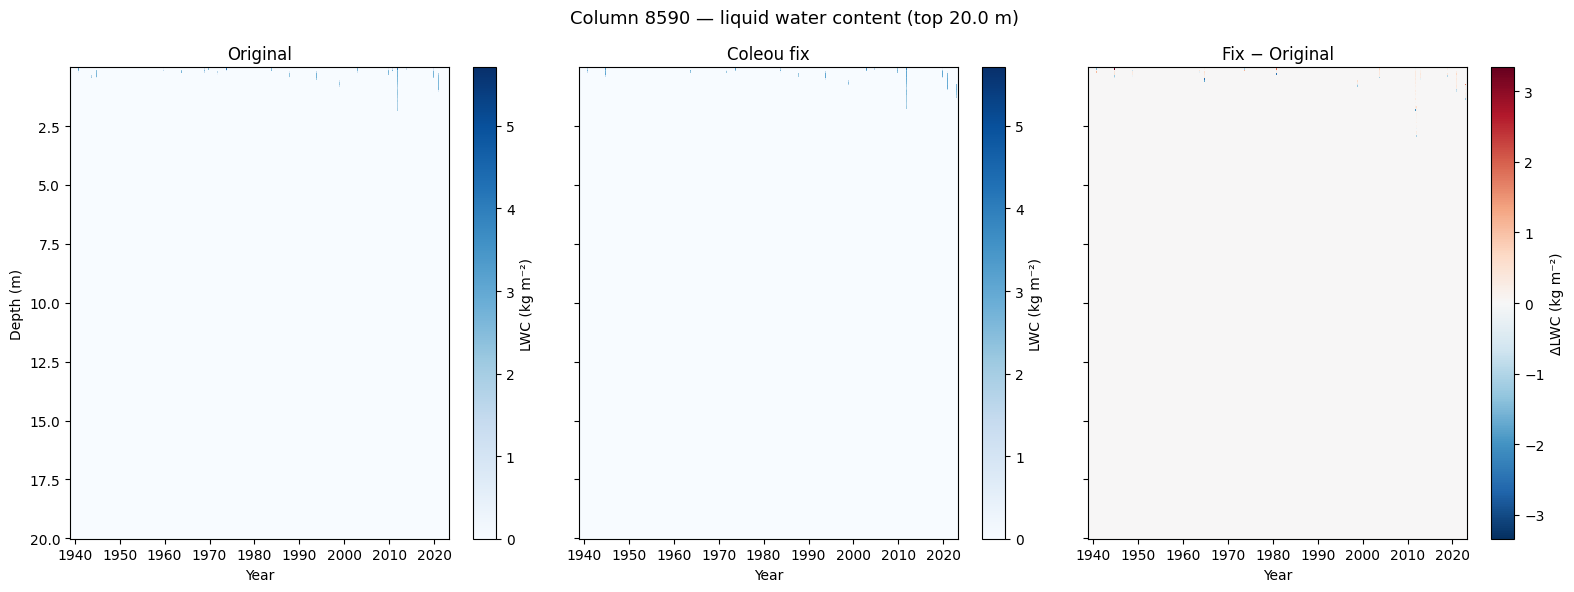

In [10]:
col = 8590

fix2d = load_2D(filepath_fix, col)
og2d  = load_2D(filepath_og,  col)

# Mean depth profile over time (use fix depths — nearly identical to og)
# depth shape: (layer, ind_t); take mean over time for y-axis
depth_mean = fix2d['depth'].mean(dim='ind_t').values  # (layer,)
max_depth = 20.0  # only show top 20 m where LWC occurs

top_layers = depth_mean <= max_depth

lwc_fix = fix2d['lwc'].values[top_layers, :]   # (layers_in_range, ind_t)
lwc_og  = og2d['lwc'].values[top_layers, :]
depth_y = depth_mean[top_layers]

vmax = max(lwc_fix.max(), lwc_og.max())

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)

# Original
im = axes[0].pcolormesh(t_monthly, depth_y, lwc_og, cmap='Blues', vmin=0, vmax=vmax)
axes[0].set_title('Original')
axes[0].set_ylabel('Depth (m)')
axes[0].invert_yaxis()
plt.colorbar(im, ax=axes[0], label='LWC (kg m⁻²)')

# Fix
im = axes[1].pcolormesh(t_monthly, depth_y, lwc_fix, cmap='Blues', vmin=0, vmax=vmax)
axes[1].set_title('Coleou fix')
plt.colorbar(im, ax=axes[1], label='LWC (kg m⁻²)')

# Difference
dlwc = lwc_fix - lwc_og
absmax = np.nanmax(np.abs(dlwc))
im = axes[2].pcolormesh(t_monthly, depth_y, dlwc, cmap='RdBu_r', vmin=-absmax, vmax=absmax)
axes[2].set_title('Fix − Original')
plt.colorbar(im, ax=axes[2], label='ΔLWC (kg m⁻²)')

for ax in axes:
    ax.set_xlabel('Year')

fig.suptitle(f'Column {col} — liquid water content (top {max_depth} m)', fontsize=13)
plt.tight_layout()
plt.show()

## Temperature at 10 m depth — closest cell to KAN-U

KAN-U AWS: 67.0003°N, −47.0253°E, 1840 m a.s.l.

The fix test run covers columns 8559–8620; the closest available column is **8583**
(66.51°N, −46.78°E, ~55 km from KAN-U — the station itself falls outside the test pointlist).
The same column is used for both runs so the comparison is consistent.

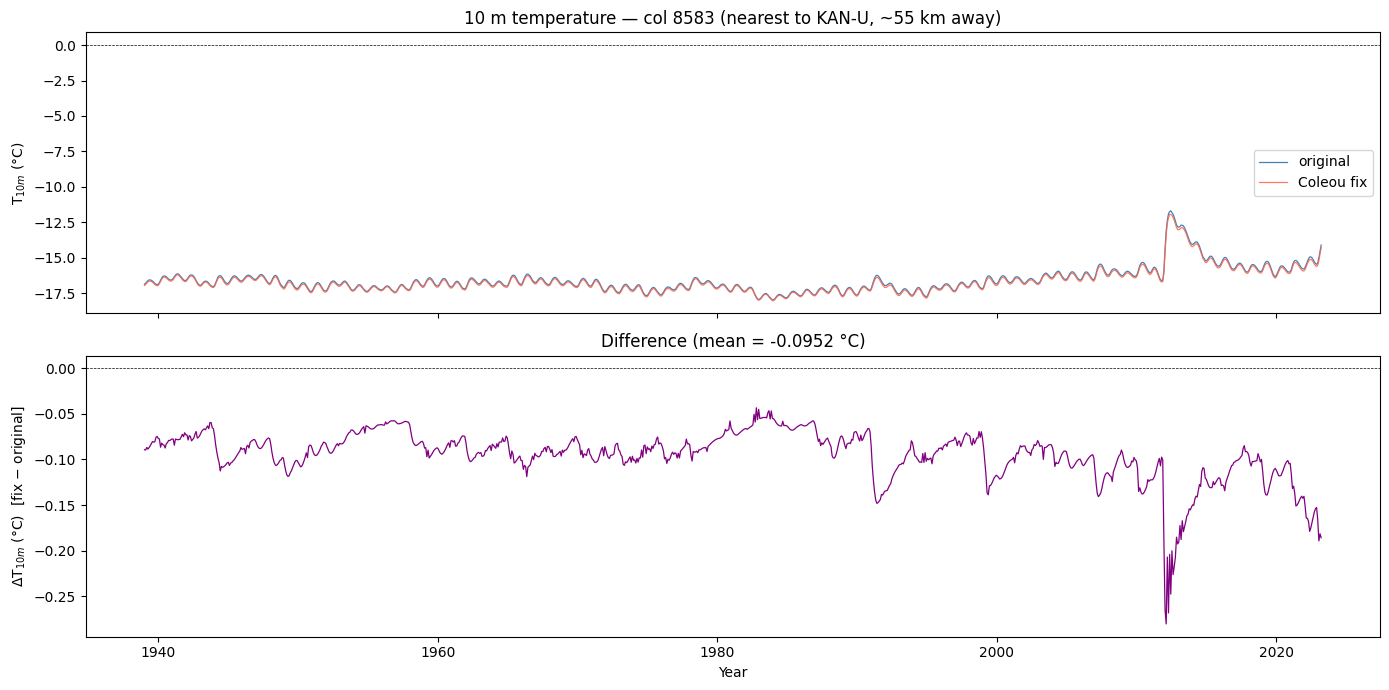

T10m mean:  fix=-16.670 °C,  original=-16.575 °C
T10m diff:  mean=-0.0952 °C,  std=0.0275 °C


In [11]:
KAN_U_COL = 8583  # closest column to KAN-U within the fix test run (~55 km)

def extract_T10m(basepath, col, target_depth=10.0):
    """Extract temperature at target_depth (m) from 2D file, one value per timestep."""
    import netCDF4 as nc
    ds = nc.Dataset(f'{basepath}/FGRN055_era055_2D_{col}.nc')
    depth = ds.variables['depth'][:]   # (layer, ind_t)
    temp  = ds.variables['temp'][:]    # (layer, ind_t)
    ds.close()

    n_t = depth.shape[1]
    T10m = np.full(n_t, np.nan)
    for t in range(n_t):
        idx = np.argmin(np.abs(depth[:, t] - target_depth))
        T10m[t] = temp[idx, t]
    return T10m - 273.15  # convert K → °C

T10m_fix = extract_T10m(filepath_fix, KAN_U_COL)
T10m_og  = extract_T10m(filepath_og,  KAN_U_COL)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Full time series
ax = axes[0]
ax.plot(t_monthly, T10m_og,  label='original',    color='steelblue', lw=0.9)
ax.plot(t_monthly, T10m_fix, label='Coleou fix',  color='tomato',    lw=0.9, alpha=0.85)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_ylabel('T$_{10m}$ (°C)')
ax.set_title(f'10 m temperature — col {KAN_U_COL} (nearest to KAN-U, ~55 km away)')
ax.legend()

# Difference
ax = axes[1]
ax.plot(t_monthly, T10m_fix - T10m_og, color='purple', lw=0.9)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_ylabel('ΔT$_{10m}$ (°C)  [fix − original]')
ax.set_xlabel('Year')
mean_dT = np.nanmean(T10m_fix - T10m_og)
ax.set_title(f'Difference (mean = {mean_dT:.4f} °C)')

plt.tight_layout()
plt.show()

print(f'T10m mean:  fix={np.nanmean(T10m_fix):.3f} °C,  original={np.nanmean(T10m_og):.3f} °C')
print(f'T10m diff:  mean={mean_dT:.4f} °C,  std={np.nanstd(T10m_fix - T10m_og):.4f} °C')

Text(0.5, 1.0, 'FDM/Figure 4 Formulation of maxpore/water mass percent')

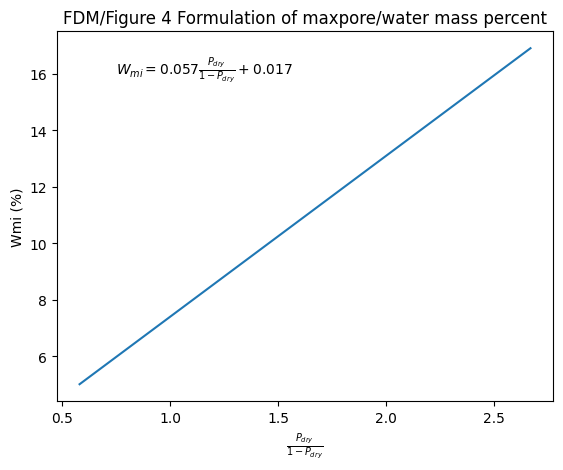

In [12]:
rho_ice = 917
rho = np.linspace(250,580)
dry_porosity = (1-rho/rho_ice)

Wmi_FDM = (0.057*dry_porosity/(1-dry_porosity) +0.017)*100

plt.plot(dry_porosity/(1-dry_porosity), Wmi_FDM)
plt.ylabel("Wmi (%)")
plt.xlabel(r"$\frac{P_{dry}}{1-P_{dry}}$")
plt.text(x=0.75,y=16,s=r"$W_{mi}=0.057\frac{P_{dry}}{1-P_{dry}}+0.017$")
plt.title("FDM/Figure 4 Formulation of maxpore/water mass percent")


Text(0.5, 1.0, 'Coleou text formulation of maxpore/water mass percent')

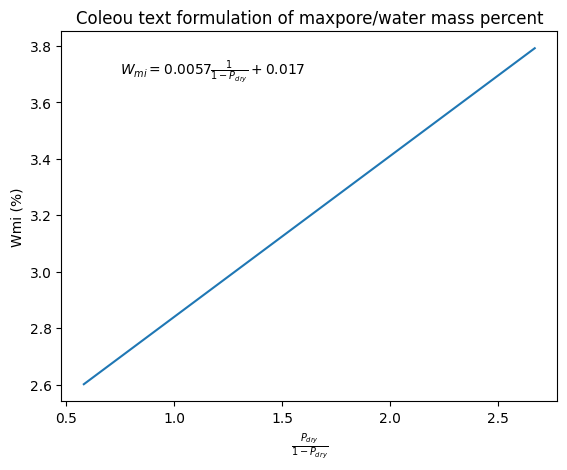

In [13]:
Wmi_paper = (0.0057/(1-dry_porosity) +0.017)*100

plt.plot(dry_porosity/(1-dry_porosity), Wmi_paper)
plt.ylabel("Wmi (%)")
plt.xlabel(r"$\frac{P_{dry}}{1-P_{dry}}$")
plt.text(x=0.75,y=3.7,s=r"$W_{mi}=0.0057\frac{1}{1-P_{dry}}+0.017$")
plt.title("Coleou text formulation of maxpore/water mass percent")

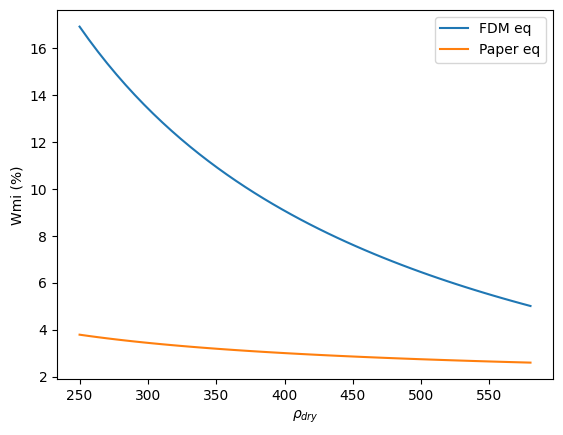

In [14]:
plt.plot(rho, Wmi_FDM, label='FDM eq')
plt.plot(rho, Wmi_paper, label='Paper eq')
plt.ylabel("Wmi (%)")
plt.xlabel(r"$\rho_{dry}$")
plt.legend()

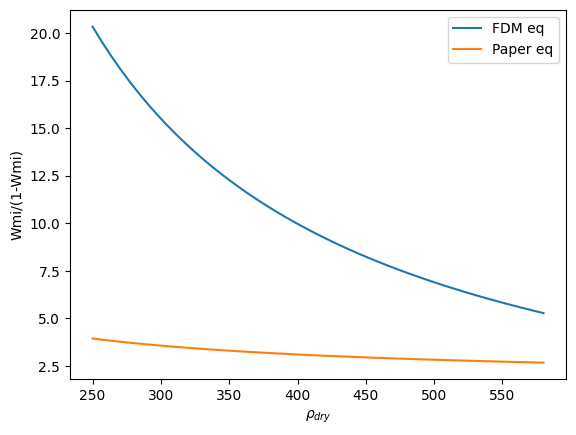

In [15]:
plt.plot(rho, (Wmi_FDM/100/(1-Wmi_FDM/100)*100), label='FDM eq')
plt.plot(rho, (Wmi_paper/100/(1-Wmi_paper/100)*100), label='Paper eq')
plt.ylabel("Wmi/(1-Wmi)")
plt.xlabel(r"$\rho_{dry}$")
plt.legend()